In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# 📊 Análise: C6 vs Mercado

## 🎯 Objetivo
Comparar as vagas do C6 com o mercado para entender diferenças no nível técnico exigido.

---

## 🧠 O que analisamos

Criamos um indicador simples baseado em:

- presença de Machine Learning (ML)
- uso de Cloud (AWS)
- tecnologias de Backend
- nível de senioridade

Isso nos dá uma visão do **nível de sofisticação técnica das vagas**.

---

## 💥 Principal resultado

> O C6, em média, busca vagas com **menor sofisticação técnica** em comparação ao mercado.

---

## 🔍 O que isso significa

- Menor presença de:
  - Machine Learning
  - Cloud
  - stacks modernas

- Menor densidade de requisitos técnicos nas descrições

---

## 🎯 Interpretação

As vagas do mercado (Nubank, iFood, Mercado Livre, etc.):

→ são mais técnicas  
→ mais específicas  
→ mais alinhadas com engenharia moderna  

Enquanto o C6:

→ tende a descrever vagas de forma mais genérica  
→ com menos sinal técnico claro  

---

## ⚠️ Implicação

> Vagas menos sofisticadas podem atrair mais candidatos, mas com menor aderência.

Isso ajuda a explicar:

- alto volume de candidatos  
- baixa taxa de aprovação no funil  

---

## 💡 Insight final

> O problema pode não estar na falta de candidatos, mas na forma como as vagas comunicam o nível técnico esperado.

In [19]:
# mercado
jobs_market = pd.read_csv("../etl/jobs_clean.csv")
skills_market = pd.read_csv("../etl/jobs_skills.csv")
features_market = pd.read_csv("../etl/jobs_features.csv")

# C6
jobs_c6 = pd.read_csv("../etl/c6_jobs_clean.csv")
skills_c6 = pd.read_csv("../etl/c6_jobs_skills.csv")
features_c6 = pd.read_csv("../etl/c6_jobs_features.csv")

In [20]:
jobs_market["group"] = "market"
jobs_c6["group"] = "c6"

jobs_all = pd.concat([jobs_market, jobs_c6], ignore_index=True)
features_all = pd.concat([features_market, features_c6], ignore_index=True)

df = jobs_all.merge(
    features_all.drop(columns=["seniority_score"]),
    on="id"
)

In [21]:
df.head()
df.groupby("group").size()

group
c6        103
market    215
dtype: int64

In [22]:
df.groupby("group")["seniority_score"].mean()

group
c6        1.281553
market    2.469767
Name: seniority_score, dtype: float64

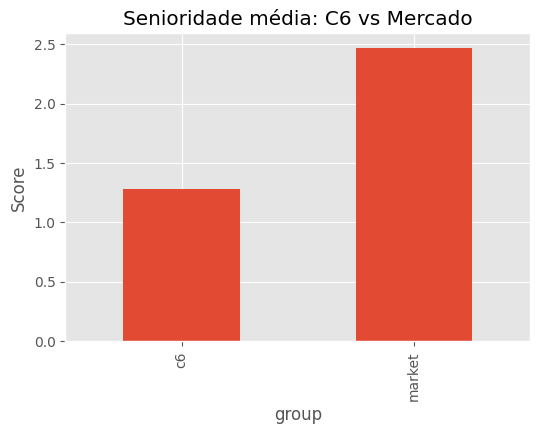

In [23]:
df.groupby("group")["seniority_score"].mean().plot(kind="bar", figsize=(6,4))
plt.title("Senioridade média: C6 vs Mercado")
plt.ylabel("Score")
plt.show()

In [24]:
df.groupby("group")[[
    "has_ml", "has_cloud", "has_backend"
]].mean()

,has_ml,has_cloud,has_backend
group,,,
c6,0.009709,0.038835,0.165049
market,0.441860,0.409302,0.362791


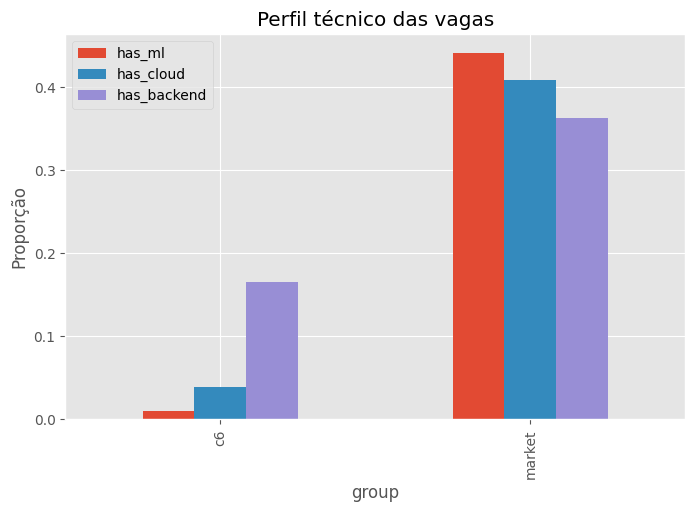

In [25]:
df.groupby("group")[[
    "has_ml", "has_cloud", "has_backend"
]].mean().plot(kind="bar", figsize=(8,5))

plt.title("Perfil técnico das vagas")
plt.ylabel("Proporção")
plt.show()

In [26]:
skills_market["group"] = "market"
skills_c6["group"] = "c6"

skills_all = pd.concat([skills_market, skills_c6])

In [27]:
skills_freq = (
    skills_all.groupby(["group", "skills"])
    .size()
    .reset_index(name="count")
)

skills_freq["pct"] = skills_freq.groupby("group")["count"].transform(lambda x: x / x.sum())

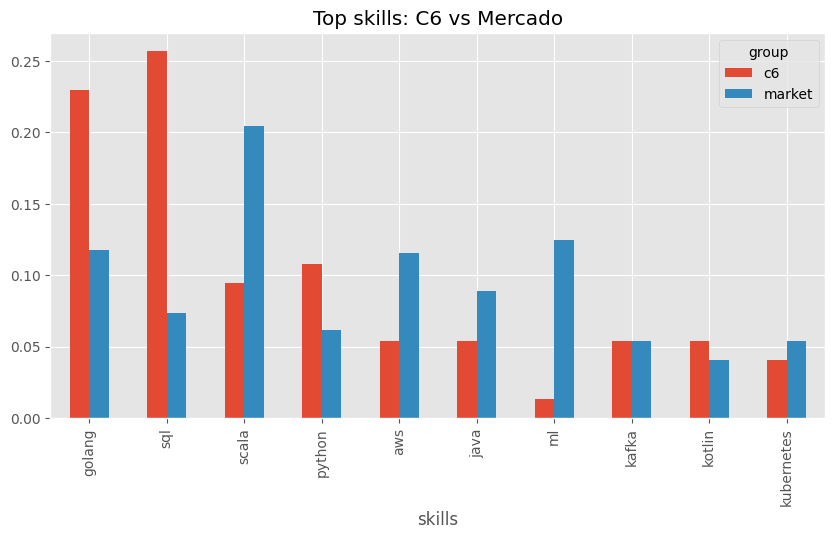

In [28]:
pivot = skills_freq.pivot_table(
    index="skills",
    columns="group",
    values="pct"
).fillna(0)

top_skills = pivot.sum(axis=1).sort_values(ascending=False).head(10).index

pivot.loc[top_skills].plot(kind="bar", figsize=(10,5))
plt.title("Top skills: C6 vs Mercado")
plt.show()

In [29]:
df["job_score"] = (
    df["has_ml"] * 2 +
    df["has_cloud"] * 2 +
    df["has_backend"] * 1 +
    df["seniority_score"]
)

In [30]:
df.groupby("group")["job_score"].mean()

group
c6        1.543689
market    4.534884
Name: job_score, dtype: float64

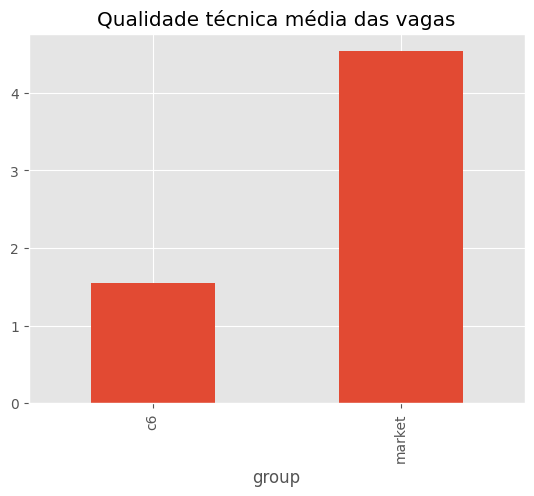

In [31]:
df.groupby("group")["job_score"].mean().plot(kind="bar")

plt.title("Qualidade técnica média das vagas")
plt.show()

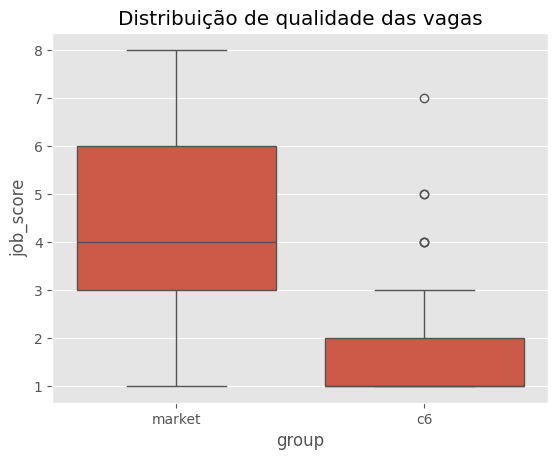

In [32]:
sns.boxplot(data=df, x="group", y="job_score")
plt.title("Distribuição de qualidade das vagas")
plt.show()

In [33]:
pivot["gap"] = pivot["market"] - pivot["c6"]
pivot.sort_values("gap", ascending=False).head(10)

group,c6,market,gap
skills,,,
ml,0.013514,0.124346,0.110832
scala,0.094595,0.204188,0.109594
aws,0.054054,0.115183,0.061129
java,0.054054,0.089005,0.034951
spark,0.000000,0.019634,0.019634
kubernetes,0.040541,0.053665,0.013124
pytorch,0.000000,0.009162,0.009162
tensorflow,0.000000,0.009162,0.009162
kafka,0.054054,0.053665,-0.000389
